#  Practical Code Challenges – Image Filtering Lab

##  Challenge 1: Kernel Size Experiment
1. Apply the uniform (box) filter using different kernel sizes:
   - 3×3
   - 5×5
   - 9×9
2. Display the results side by side.
3. Describe how increasing kernel size affects:
   - Blur strength
   - Image details
   - Sharp edges

---

##  Challenge 2: Gaussian Sigma Investigation
1. Apply Gaussian blur with:
   - Small sigma (e.g., 1)
   - Medium sigma (e.g., 5)
   - Large sigma (e.g., 15)
2. Keep kernel size constant.
3. Observe and explain:
   - What role does sigma play?
   - How is Gaussian blur different from uniform blur visually?

---

##  Challenge 3: Manual Convolution
1. Create your own custom 3×3 kernel using NumPy.
2. Apply it using `cv2.filter2D()`.
3. Try:
   - A sharpening kernel
   - An edge detection kernel
4. Compare results with built-in filters.

---

##  Challenge 4: Noise Removal Test
1. Add artificial noise to the original image:
   - Gaussian noise
   - Salt-and-pepper noise
2. Apply:
   - Uniform filter
   - Gaussian filter
3. Which filter performs better for each noise type?
4. Justify your answer with visual comparison.

---

##  Challenge 5: Edge Preservation Study
1. Blur the image using:
   - Box filter
   - Gaussian filter
2. Compare how edges are affected.
3. Measure pixel intensity differences across edges before and after filtering.
4. Which method preserves structure better?

---

##  Challenge 6: Performance Comparison
1. Measure execution time for:
   - `cv2.filter2D()`
   - `cv2.GaussianBlur()`
2. Run each filter multiple times.
3. Calculate average processing time.
4. Which method is faster? Why?

---

##  Challenge 7: Kernel Normalization Test
1. Create a kernel that is NOT normalized (sum ≠ 1).
2. Apply it to the image.
3. Observe what happens to brightness.
4. Fix the issue by normalizing the kernel.

---

#  Final Challenge: Smart Filter Selector
Create a mini program that:
- Asks the user to choose:
  - Uniform filter
  - Gaussian filter
- Asks for kernel size and sigma (if Gaussian)
- Applies the selected filter
- Displays original and filtered images side by side

Make it structured, reusable, and well-commented.

Text(0.5, 1.0, 'blurred with 9x9 filter')

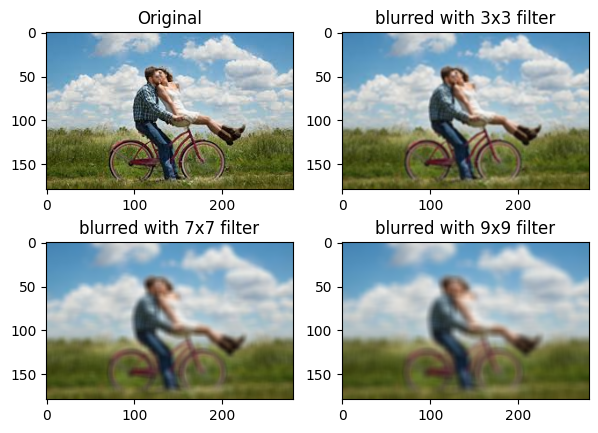

In [45]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


image = cv2.imread('images.jpeg')

# Creating our 3 x 3 kernel
kernel_3x3 = np.ones((3, 3), np.float32) / 9

# We use the cv2.fitler2D to conovlve the kernal with an image
blurred = cv2.filter2D(image, -1, kernel_3x3)


# Creating our 7 x 7 kernel
kernel_7x7 = np.ones((7, 7), np.float32) / 49
blurred2 = cv2.filter2D(image, -1, kernel_7x7)

kernel_9x9 = np.ones((9, 9), np.float32) / 81
blurred3 = cv2.filter2D(image, -1, kernel_9x9)


plt.figure(figsize=[7,5]) # Adjusted figsize for better display of 4 plots
plt.subplot(221);plt.imshow(image[...,::-1]);plt.title("Original")
plt.subplot(222);plt.imshow(blurred[...,::-1]);plt.title("blurred with 3x3 filter")
plt.subplot(223);plt.imshow(blurred2[...,::-1]);plt.title("blurred with 7x7 filter")
plt.subplot(224);plt.imshow(blurred3[...,::-1]);plt.title("blurred with 9x9 filter")

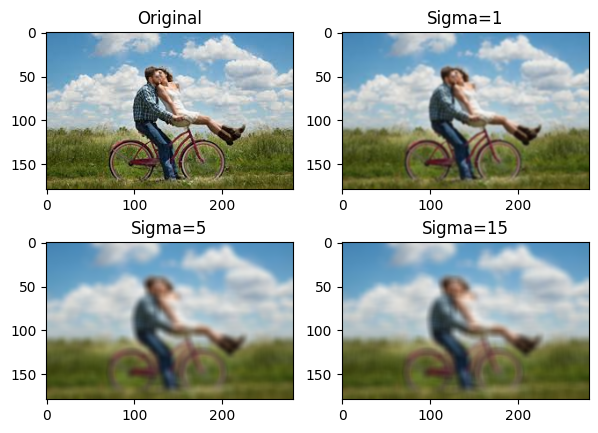

In [46]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Challenge 2: Gaussian Sigma Investigation
image = cv2.imread('images.jpeg')

# Applying Gaussian blur with constant kernel size (9x9) and different sigma values
gaussian_s1 = cv2.GaussianBlur(image, (9, 9), 1)
gaussian_s5 = cv2.GaussianBlur(image, (9, 9), 5)
gaussian_s15 = cv2.GaussianBlur(image, (9, 9), 15)

plt.figure(figsize=[7, 5])
plt.subplot(221); plt.imshow(image[...,::-1]); plt.title("Original")
plt.subplot(222); plt.imshow(gaussian_s1[...,::-1]); plt.title("Sigma=1")
plt.subplot(223); plt.imshow(gaussian_s5[...,::-1]); plt.title("Sigma=5")
plt.subplot(224); plt.imshow(gaussian_s15[...,::-1]); plt.title("Sigma=15")
plt.show()

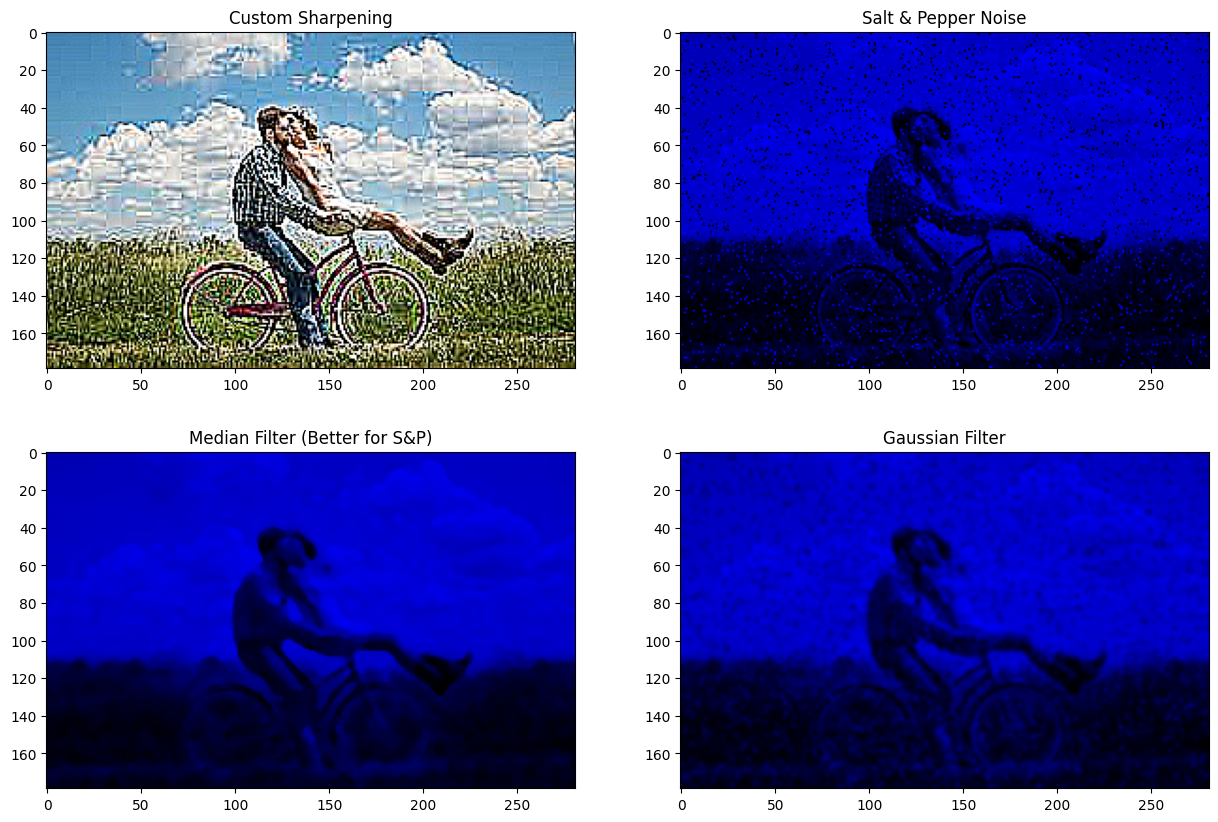

In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Challenge 3 & 4: Manual Convolution and Noise Removal
image = cv2.imread('images.jpeg')

# Custom Sharpening Kernel
kernel_sharpen = np.array([[-1,-1,-1], [-1,9,-1], [-1,-1,-1]])
sharpened = cv2.filter2D(image, -1, kernel_sharpen)

# Adding Salt and Pepper Noise
noise = np.zeros(image.shape, np.uint8)
cv2.randu(noise, 0, 255)
salt_pepper = image.copy()
salt_pepper[noise < 10] = 0
salt_pepper[noise > 245] = 255

# Comparing Filters for Noise Removal
median_denoised = cv2.medianBlur(salt_pepper, 5)
gaussian_denoised = cv2.GaussianBlur(salt_pepper, (5, 5), 0)

plt.figure(figsize=[15, 10])
plt.subplot(221); plt.imshow(sharpened[...,::-1]); plt.title("Custom Sharpening")
plt.subplot(222); plt.imshow(salt_pepper[...,::-1]); plt.title("Salt & Pepper Noise")
plt.subplot(223); plt.imshow(median_denoised[...,::-1]); plt.title("Median Filter (Better for S&P)")
plt.subplot(224); plt.imshow(gaussian_denoised[...,::-1]); plt.title("Gaussian Filter")
plt.show()

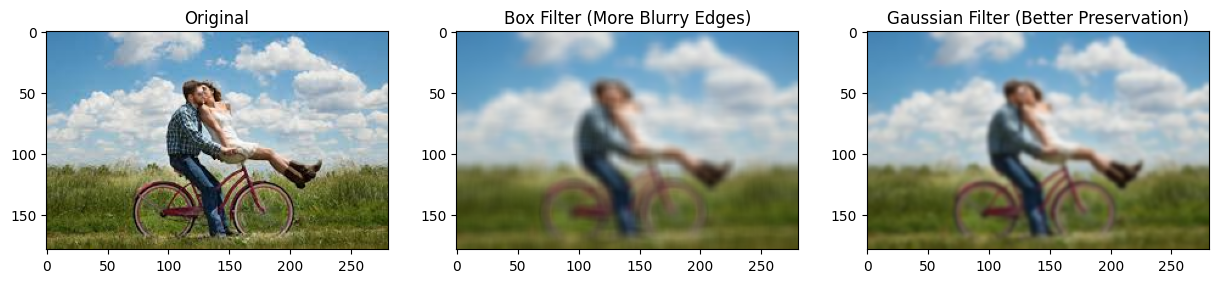

In [48]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Challenge 5: Edge Preservation Study
image = cv2.imread('images.jpeg')

# Apply filters
box_blur = cv2.blur(image, (9, 9))
gaussian_blur = cv2.GaussianBlur(image, (9, 9), 0)

# Visualization
plt.figure(figsize=[15, 5])
plt.subplot(131); plt.imshow(image[...,::-1]); plt.title("Original")
plt.subplot(132); plt.imshow(box_blur[...,::-1]); plt.title("Box Filter (More Blurry Edges)")
plt.subplot(133); plt.imshow(gaussian_blur[...,::-1]); plt.title("Gaussian Filter (Better Preservation)")
plt.show()

In [49]:
import cv2
import time

# Challenge 6: Performance Comparison
image = cv2.imread('images.jpeg')
iterations = 100

# Measure filter2D
start = time.time()
for _ in range(iterations):
    cv2.filter2D(image, -1, np.ones((5,5), np.float32)/25)
end = time.time()
print(f"Average filter2D time: {(end - start) / iterations:.6f} seconds")

# Measure GaussianBlur
start = time.time()
for _ in range(iterations):
    cv2.GaussianBlur(image, (5, 5), 0)
end = time.time()
print(f"Average GaussianBlur time: {(end - start) / iterations:.6f} seconds")

Average filter2D time: 0.000595 seconds
Average GaussianBlur time: 0.000155 seconds


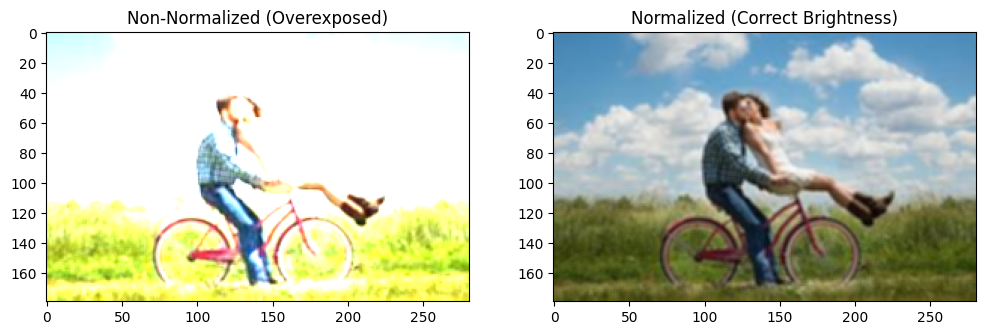

In [50]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Challenge 7: Kernel Normalization Test
image = cv2.imread('images.jpeg')

# Non-normalized kernel (Sum = 3 instead of 1)
kernel_raw = np.ones((3, 3), np.float32) / 3
# Normalized kernel (Sum = 1)
kernel_norm = np.ones((3, 3), np.float32) / 9

bright_img = cv2.filter2D(image, -1, kernel_raw)
correct_img = cv2.filter2D(image, -1, kernel_norm)

plt.figure(figsize=[12, 5])
plt.subplot(121); plt.imshow(bright_img[...,::-1]); plt.title("Non-Normalized (Overexposed)")
plt.subplot(122); plt.imshow(correct_img[...,::-1]); plt.title("Normalized (Correct Brightness)")
plt.show()